# Data Preprocessing — *Bipes biporus* MaxEnt Workflow
**Notebook 1 of 2 — San Diego Natural History Museum**

*Three variable sets tested in parallel: **BioClim + DEM**, **Envirem**, and **Combined**. Outputs feed into `02_modeling.ipynb`.*

### Roadmap
1. **Setup & Imports** — packages, paths, variable setup, configuration
2. **Study Area** — load and reproject boundary shapefile
3. **Occurrences** — load CSV, validate, spatial thinning
4. **Environmental Layers** — clip, align, mask, export rasters
5. **Variable Selection** — deduplication and collinearity screening


### To reuse with different data

Sections 2–4 run automatically. All edits go in **§1** and optionally **§5**.

- **§1** — all project-specific parameters (species, paths, column names, variable sets); configure once before running
- **§5** — two-step variable filtering: manual exclusions first (§5.1, domain knowledge), then automated collinearity screening (§5.2)

## 1. Setup & Imports

Run: `Kernel → Restart & Run All`

### 1.1 Import Packages

In [1]:
# Checks that each package is at the exact pinned version; reinstalls automatically if not.
import subprocess, sys

_EXACT_VERSIONS = {          # package → required version
    "numpy"       : "2.2.4",
    "pandas"      : "2.2.3",
    "geopandas"   : "1.1.3",
    "rasterio"    : "1.5.0",
    "matplotlib"  : "3.10.1",
    "seaborn"     : "0.13.2",
    "scipy"       : "1.15.2",
    "tqdm"        : "4.67.3",
    "scikit-learn": "1.5.2",
    "elapid"      : "1.0.3",
    "shapely"     : "2.1.2",
    "pyproj"      : "3.7.2",
}

_IMPORT_AS = {"scikit-learn": "sklearn"}   # install name differs from import name

for pkg, exact_ver in _EXACT_VERSIONS.items():
    import_name = _IMPORT_AS.get(pkg, pkg)
    try:
        mod = __import__(import_name)
        installed = getattr(mod, "__version__", "0.0")
        if installed != exact_ver:
            print(f"  reinstalling {pkg} {installed} -> {exact_ver} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install",
                                    f"{pkg}=={exact_ver}", "-q"])
            print(f"  done: {pkg}=={exact_ver}")
        else:
            print(f"  OK  {pkg} {installed}")
    except ImportError:
        print(f"  installing: {pkg}=={exact_ver} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                                f"{pkg}=={exact_ver}", "-q"])
        print(f"  installed: {pkg}=={exact_ver}")

  OK  numpy 2.2.4
  OK  pandas 2.2.3
  OK  geopandas 1.1.3
  OK  rasterio 1.5.0
  OK  matplotlib 3.10.1
  OK  seaborn 0.13.2
  OK  scipy 1.15.2
  OK  tqdm 4.67.3
  OK  scikit-learn 1.5.2
  OK  elapid 1.0.3
  OK  shapely 2.1.2
  OK  pyproj 3.7.2


In [2]:
# ── Standard scientific ───────────────────────────────────────────────────────
import os, math, warnings
import numpy  as np
import pandas as pd
import geopandas as gpd
import scipy

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display

# ── Raster / geo ──────────────────────────────────────────────────────────────
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds as win_from_bounds
import rasterio.transform as rtransform
import pyproj as _pyproj
from pyproj import Transformer as _Transformer

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
%matplotlib inline

### 1.2 File Paths
> ✎ **Edit for every new project** — species name, CSV, shapefile, raster directories, and output folders.

In [3]:
# Edit these paths to match your project.

# ── Input: species data ───────────────────────────────────────────────────────
SPECIES_NAME   = 'Bipes_biporus'   # used in output filenames and plot titles
                                    # spaces are converted to underscores automatically; avoid / \ : * ? " < > |
SPECIES_NAME   = SPECIES_NAME.strip().replace(' ', '_').replace('(','').replace(')','').replace('/','-')

SPECIES_CSV    = os.path.join('Raw Datasets', 'Species data', 'Bipes_Excluded Points.csv')
STUDY_AREA_SHP = os.path.join('Raw Datasets', 'Species data', 'BajaPeninsula.shp')

# ── CSV column names ──────────────────────────────────────────────────────────
LAT_COL     = 'Latitude'    # latitude column in the occurrence CSV
LON_COL     = 'Longitude'   # longitude column in the occurrence CSV
SPECIES_COL = 'Species'     # species name column (used when exporting)

# ── Input: environmental rasters ─────────────────────────────────────────────
DATA_ROOT   = 'Raw Datasets'
BIOCLIM_DIR = os.path.join(DATA_ROOT, 'BioClim')
ENVIREM_DIR = os.path.join(DATA_ROOT, 'Envirem')
DEM_DIR     = os.path.join(DATA_ROOT, 'USGS_DEM_20250902')

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR      = 'Processed' # processed occurrence files and rasters are saved here
SPECIES_OUT_DIR = os.path.join(OUTPUT_DIR, 'species')     
BIOCLIM_OUT_DIR = os.path.join(OUTPUT_DIR, 'BioClim')  
ENVIREM_OUT_DIR = os.path.join(OUTPUT_DIR, 'Envirem')   
DEM_OUT_DIR     = os.path.join(OUTPUT_DIR, 'DEM')

### 1.3 Configuration
> ✎ **Edit only when needed** — coordinate system, raster resolution, and buffer degree of study area

In [4]:
COORDINATE_SYSTEM     = 'EPSG:32611'   # target CRS for all outputs; change to any EPSG (e.g. 'EPSG:32611' for UTM zone 11N)

RASTER_RES_ARCSEC     = 30            # source raster resolution in arcseconds; WorldClim default = 30 (~1 km); None = auto-detect

STUDY_AREA_BUFFER_DEG = 1.0           # buffer when clipping source rasters — always in degrees (applied in WGS84);
                                      # increase for complex terrain to avoid edge artefacts

NODATA_VALUE          = -9999.0

### 1.4 Variable Setup
> ✎ **Edit when changing environmental data** — define variable names, data sources, and analysis sets.

In [5]:
# ── PART A: Variable names ────────────────────────────────────────────────────
# Maps short key → full display name for plot labels and exported filenames.
# Variables not listed here are saved using their short key.
BIOCLIM_NAMES = {
    'bio_1' : 'Annual Mean Temperature',
    'bio_2' : 'Mean Diurnal Range',
    'bio_3' : 'Isothermality',
    'bio_4' : 'Temperature Seasonality',
    'bio_5' : 'Max Temp of Warmest Month',
    'bio_6' : 'Min Temp of Coldest Month',
    'bio_7' : 'Temperature Annual Range',
    'bio_8' : 'Mean Temp of Wettest Quarter',
    'bio_9' : 'Mean Temp of Driest Quarter',
    'bio_10': 'Mean Temp of Warmest Quarter',
    'bio_11': 'Mean Temp of Coldest Quarter',
    'bio_12': 'Annual Precipitation',
    'bio_13': 'Precipitation of Wettest Month',
    'bio_14': 'Precipitation of Driest Month',
    'bio_15': 'Precipitation Seasonality',
    'bio_16': 'Precipitation of Wettest Quarter',
    'bio_17': 'Precipitation of Driest Quarter',
    'bio_18': 'Precipitation of Warmest Quarter',
    'bio_19': 'Precipitation of Coldest Quarter',
}
DEM_NAMES = {'gt30w140n40': 'Elevation (USGS DEM)'}
ENVIREM_NAMES = {
    'annualPET'               : 'Annual Potential Evapotranspiration',
    'aridityIndexThornthwaite': 'Aridity Index (Thornthwaite)',
    'climaticMoistureIndex'   : 'Climatic Moisture Index',
    'continentality'          : 'Continentality Index',
    'embergerQ'               : 'EmbergerQ',
    'growingDegDays0'         : 'Growing Degree Days (base 0 C)',
    'growingDegDays5'         : 'Growing Degree Days (base 5 C)',
    'maxTempColdest'          : 'Max Temp of Coldest Period',
    'minTempWarmest'          : 'Min Temp of Warmest Period',
    'monthCountByTemp10'      : 'Month Count Temp above 10 C',
    'PETColdestQuarter'       : 'PET of Coldest Quarter',
    'PETDriestQuarter'        : 'PET of Driest Quarter',
    'PETseasonality'          : 'PET Seasonality',
    'PETWarmestQuarter'       : 'PET of Warmest Quarter',
    'PETWettestQuarter'       : 'PET of Wettest Quarter',
    'thermicityIndex'         : 'Thermicity Index',
    'topoWet'                 : 'Topographic Wetness Index',
    'tri'                     : 'Terrain Ruggedness Index',
}

# ── PART B: Data sources ──────────────────────────────────────────────────────
# Maps each names dict to: input directory, output directory.
# §4.1 auto-scans each directory and matches .tif files to the keys above.
SOURCES = [
    (BIOCLIM_NAMES, BIOCLIM_DIR, BIOCLIM_OUT_DIR),
    (DEM_NAMES,     DEM_DIR,     DEM_OUT_DIR),
    (ENVIREM_NAMES, ENVIREM_DIR, ENVIREM_OUT_DIR),
]

# ── PART C: Variable analysis sets ─────────────────────────────────────────────────────
# Add, remove, or rename entries freely. 
VARIABLE_SETS = {
    'BioClim_DEM': list(BIOCLIM_NAMES.keys()) + list(DEM_NAMES.keys()),
    'Envirem':     list(ENVIREM_NAMES.keys()),
    'Combined':    list(BIOCLIM_NAMES.keys()) + list(DEM_NAMES.keys()) + list(ENVIREM_NAMES.keys()),
}

### 1.5 Output & Confirmation
Creates output folders, auto-detects resolution if needed, and verifies all input paths.

In [6]:
# Create all output folders — derived from SOURCES automatically.
for folder in [OUTPUT_DIR, SPECIES_OUT_DIR] + [out_dir for _, _, out_dir in SOURCES]:
    os.makedirs(folder, exist_ok=True)

# Auto-detect source raster resolution in arcseconds if RASTER_RES_ARCSEC is None.
if RASTER_RES_ARCSEC is None:
    _first_src_dir = SOURCES[0][1]
    _sample_files  = [f for f in os.listdir(_first_src_dir) if f.endswith('.tif')]
    if not _sample_files:
        raise FileNotFoundError(
            f'No .tif files in {_first_src_dir}. '
            'Check the first entry in SOURCES (§1.4), or set RASTER_RES_ARCSEC manually in §1.3.'
        )
    with rasterio.open(os.path.join(_first_src_dir, _sample_files[0])) as _src:
        RASTER_RES_ARCSEC = round(_src.res[0] * 3600)
    print(f'Source resolution auto-detected: {RASTER_RES_ARCSEC} arcsec')
else:
    print(f'Source resolution : {RASTER_RES_ARCSEC} arcsec')

# Input path check
print('\nInput path check:')
all_ok = True
_fixed_paths  = [('Study area shapefile',   STUDY_AREA_SHP),
                 ('Species occurrence CSV', SPECIES_CSV)]
_source_paths = [(f'{os.path.basename(out_dir)} directory', src_dir)
                 for _, src_dir, out_dir in SOURCES]

for label, path in _fixed_paths + _source_paths:
    ok = os.path.exists(path)
    all_ok = all_ok and ok
    print(f'  {"OK" if ok else "MISSING"}  {label:<30}  {path}')

print()
if all_ok:
    print('All inputs found — ready to continue.')
else:
    print('WARNING: Fix the missing paths above before running the rest of the notebook.')

Source resolution : 30 arcsec

Input path check:
  OK  Study area shapefile            Raw Datasets/Species data/BajaPeninsula.shp
  OK  Species occurrence CSV          Raw Datasets/Species data/Bipes_Excluded Points.csv
  OK  BioClim directory               Raw Datasets/BioClim
  OK  DEM directory                   Raw Datasets/USGS_DEM_20250902
  OK  Envirem directory               Raw Datasets/Envirem

All inputs found — ready to continue.


## 2. Study Area

*Study area boundary loaded from the shapefile. All occurrence records and environmental layers will be clipped to this region.*

In [ ]:
# ── Load study area boundary ──────────────────────────────────────────────────
study_area_raw = gpd.read_file(STUDY_AREA_SHP)
print(f'Records in shapefile : {len(study_area_raw)}')
print(f'Source CRS           : {study_area_raw.crs}')

if study_area_raw.crs is None:
    study_area = study_area_raw.set_crs(COORDINATE_SYSTEM)
    print(f'No CRS found in file — assigned {COORDINATE_SYSTEM}')
elif study_area_raw.crs != _pyproj.CRS(COORDINATE_SYSTEM):
    study_area = study_area_raw.to_crs(COORDINATE_SYSTEM)
    print(f'Reprojected to {COORDINATE_SYSTEM}')
else:
    study_area = study_area_raw
    print(f'CRS already matches target ({COORDINATE_SYSTEM})')

_sa_out = os.path.join(OUTPUT_DIR, 'study_area.shp')
study_area.to_file(_sa_out)
print(f'Study area exported  → {_sa_out}')

# ── Thinning resolution = actual output raster pixel size ─────────────────────
# Open the first source raster, compute what the output pixel size will be after
# reprojection to COORDINATE_SYSTEM, and use that for spatial thinning.
_crs_obj   = _pyproj.CRS(COORDINATE_SYSTEM)
_first_tif = next(
    os.path.join(SOURCES[0][1], f)
    for f in sorted(os.listdir(SOURCES[0][1]))
    if f.endswith('.tif') and not f.endswith('.aux.xml')
)
with rasterio.open(_first_tif) as _ref:
    _src_crs = _ref.crs
    _sa_src  = study_area.to_crs(_src_crs)
    _b       = _sa_src.total_bounds
    _buf     = STUDY_AREA_BUFFER_DEG if _src_crs.is_geographic else STUDY_AREA_BUFFER_DEG * 111_000
    _win     = win_from_bounds(
        _b[0]-_buf, _b[1]-_buf, _b[2]+_buf, _b[3]+_buf,
        transform=_ref.transform,
    ).round_offsets().round_lengths()
    _src_tfm = _ref.window_transform(_win)
    _win_h, _win_w = int(_win.height), int(_win.width)

if _crs_obj == _src_crs:
    THINNING_RESOLUTION = abs(_src_tfm.a)
else:
    _out_tfm, _, _ = calculate_default_transform(
        _src_crs, _crs_obj, _win_w, _win_h,
        *rtransform.array_bounds(_win_h, _win_w, _src_tfm),
    )
    THINNING_RESOLUTION = abs(_out_tfm.a)

_unit = 'deg' if _crs_obj.is_geographic else 'm'
print(f'Thinning resolution  : {THINNING_RESOLUTION:.4f} {_unit}')

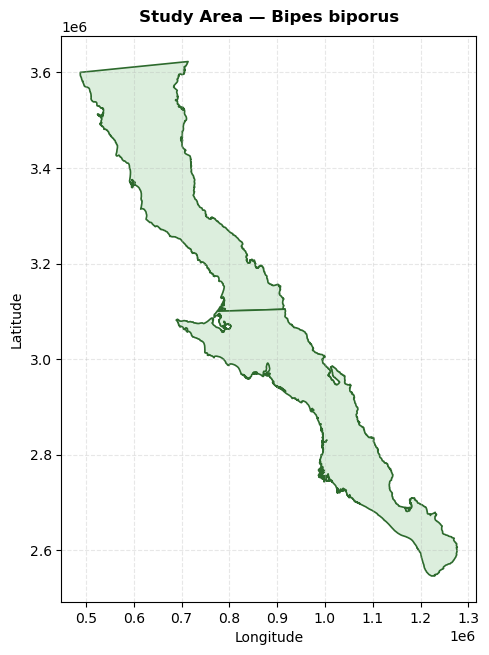

Saved → Processed/01_Bipes_biporus_study_area.png


In [8]:
# ── Map: study area boundary ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 9))
study_area.plot(ax=ax, color='#dceedd', edgecolor='#2d6a2d', linewidth=1.2)

ax.set_title(f'Study Area — {SPECIES_NAME.replace("_", " ")}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, f'01_{SPECIES_NAME}_study_area.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 3. Species Occurrence Data

### 3.1. Load & Validate

In [9]:
# ── Load occurrence CSV ───────────────────────────────────────────────────────
occ = pd.read_csv(SPECIES_CSV)

print(f'File    : {SPECIES_CSV}')
print(f'Rows    : {occ.shape[0]}')
print(f'Columns : {list(occ.columns)}')
print()
display(occ.head())

File    : Raw Datasets/Species data/Bipes_Excluded Points.csv
Rows    : 55
Columns : ['Species', 'Latitude', 'Longitude']



,Species,Latitude,Longitude
0,Bipes biporus,28.28278,-113.99917
1,Bipes biporus,28.26377,-113.94238
2,Bipes biporus,28.24540,-113.47800
3,Bipes biporus,24.13083,-110.33850
4,Bipes biporus,23.45000,-110.21670


In [10]:
# ── Assign coordinates and reproject to target CRS ────────────────────────────
# CSV lon/lat are always WGS84 degrees — assign 4326 first, then reproject.
occ_gdf = gpd.GeoDataFrame(
    occ,
    geometry=gpd.points_from_xy(occ[LON_COL], occ[LAT_COL]),
    crs='EPSG:4326',
).to_crs(COORDINATE_SYSTEM)

print(f'Coordinate system : {occ_gdf.crs}')
print(f'Records           : {len(occ_gdf)}')

Coordinate system : EPSG:32611
Records           : 55


### 3.2. Spatial Thinning

Museum records tend to cluster near accessible localities; without correction, MaxEnt mistakes sampling density for habitat suitability. This step keeps one occurrence per raster grid cell — the same resolution as the environmental layers — which removes sampling-intensity bias and also removes exact-coordinate duplicates.

Grid cell size  : 822.3 m ≈ 0.82 km
Before thinning : 55 records
After thinning  : 49 records
Removed         : 6 duplicates / clustered records



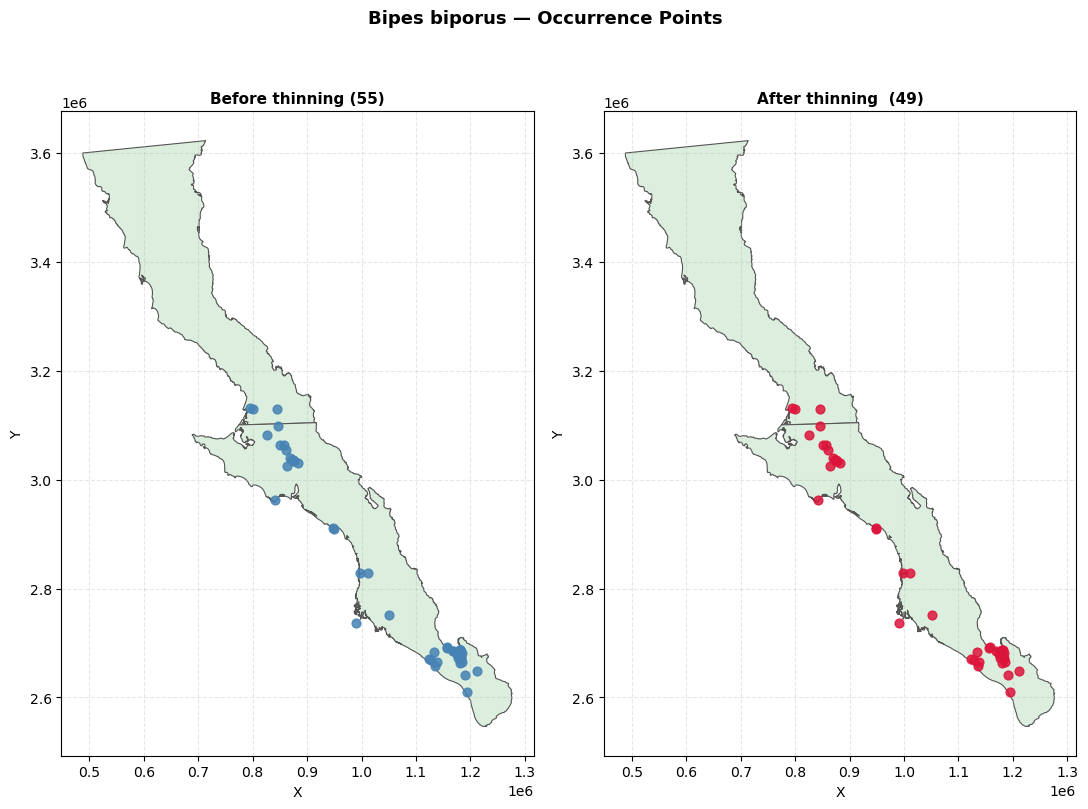

Saved → Processed/02_Bipes_biporus_occurrences_thinned.png


In [11]:
# ── Spatial thinning: keep one occurrence per raster grid cell ────────────────

occ_gdf = occ_gdf.copy()
_xmin, _ymin = study_area.total_bounds[:2]
occ_gdf['_grid_col'] = np.floor((occ_gdf.geometry.x - _xmin) / THINNING_RESOLUTION).astype(int)
occ_gdf['_grid_row'] = np.floor((occ_gdf.geometry.y - _ymin) / THINNING_RESOLUTION).astype(int)

n_before = len(occ_gdf)
occ_thinned = (
    occ_gdf
    .drop_duplicates(subset=['_grid_col', '_grid_row'])
    .drop(columns=['_grid_col', '_grid_row'])
    .reset_index(drop=True)
)
n_after = len(occ_thinned)

_is_geo = _pyproj.CRS(COORDINATE_SYSTEM).is_geographic
if _is_geo:
    print(f'Grid cell size  : {THINNING_RESOLUTION:.5f} deg '
          f'= {THINNING_RESOLUTION * 3600:.0f} arcsec '
          f'≈ {THINNING_RESOLUTION * 111:.1f} km')
else:
    print(f'Grid cell size  : {THINNING_RESOLUTION:.1f} m ≈ {THINNING_RESOLUTION / 1000:.2f} km')
print(f'Before thinning : {n_before} records')
print(f'After thinning  : {n_after} records')
print(f'Removed         : {n_before - n_after} duplicates / clustered records')
print()

fig, axes = plt.subplots(1, 2, figsize=(11, 8))
for ax, (pts, title, color) in zip(axes, [
    (occ_gdf,     f'Before thinning ({n_before})', 'steelblue'),
    (occ_thinned, f'After thinning  ({n_after})',  'crimson'),
]):
    study_area.plot(ax=ax, color='#dceedd', edgecolor='#555', linewidth=0.8)
    pts.plot(ax=ax, color=color, markersize=40, zorder=3, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude' if _is_geo else 'X')
    ax.set_ylabel('Latitude'  if _is_geo else 'Y')
    ax.grid(True, ls='--', alpha=0.3)

plt.suptitle(f'{SPECIES_NAME.replace("_", " ")} — Occurrence Points',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, f'02_{SPECIES_NAME}_occurrences_thinned.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### 3.3. Export Cleaned Occurrences

In [12]:
# ── Export cleaned occurrence records ─────────────────────────────────────────
out_csv = os.path.join(SPECIES_OUT_DIR, 'occurrences_cleaned.csv')
out_shp = os.path.join(SPECIES_OUT_DIR, 'occurrences_cleaned.shp')

export_cols = [c for c in [SPECIES_COL, LON_COL, LAT_COL] if c in occ_thinned.columns]
occ_thinned[export_cols].to_csv(out_csv, index=False)
occ_thinned.to_file(out_shp)

print(f'Exported {len(occ_thinned)} cleaned records:')
print(f'  CSV → {out_csv}')
print(f'  SHP → {out_shp}')

Exported 49 cleaned records:
  CSV → Processed/species/occurrences_cleaned.csv
  SHP → Processed/species/occurrences_cleaned.shp


## 4. Environmental Layers

### 4.1 Variable Registry

In [13]:

# Auto-matching & derived lookups  
def _key_in_file(key, filename):
    """True if 'key' appears in filename stem at a word boundary."""
    stem = os.path.splitext(filename)[0]
    pos  = stem.find(key)
    if pos == -1:
        return False
    end = pos + len(key)
    return end == len(stem) or not (stem[end].isalnum() or stem[end] == '_')

LAYERS = {}
SOURCE_KEYS = {} 

for names_dict, src_dir, out_dir in SOURCES:
    src_label = os.path.basename(out_dir)   # e.g. 'BioClim', 'DEM', 'Envirem'
    SOURCE_KEYS[src_label] = []
    tifs = sorted([f for f in os.listdir(src_dir)
                   if f.endswith('.tif') and not f.endswith('.aux.xml')])

    for k, full_name in names_dict.items():
        matches = [f for f in tifs if _key_in_file(k, f)]

        if not matches and len(names_dict) == 1 and len(tifs) == 1:
            matches = tifs   # single file + single key → auto-match (e.g. DEM)

        if len(matches) == 1:
            LAYERS[k] = (os.path.join(src_dir, matches[0]), full_name, out_dir)
            SOURCE_KEYS[src_label].append(k)
        elif not matches:
            print(f'  WARNING: no .tif found for "{k}" in {src_dir}')
        else:
            print(f'  WARNING: {len(matches)} files match "{k}" — {matches}')

all_paths       = {k: v[0] for k, v in LAYERS.items()}
ALL_NAMES       = {k: v[1] for k, v in LAYERS.items()}
destination_dir = {k: v[2] for k, v in LAYERS.items()}

SOURCE_NAMES = {                                  # {source_label: {key: full_name}}
    label: {k: LAYERS[k][1] for k in keys}
    for label, keys in SOURCE_KEYS.items()
}

def _safe_filename(full_name):
    return (full_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '-').strip('_'))

# ── Registry summary ──────────────────────────────────────────────────────────
counts = '  |  '.join(f'{label}: {len(keys)}' for label, keys in SOURCE_KEYS.items())
print(f'Registered {len(LAYERS)} layers  ({counts})\n')
rows = []
for k, (path, name, out_dir) in LAYERS.items():
    src_label = os.path.basename(out_dir)
    rows.append({'Source': src_label, 'Key': k,
                 'Full Name': name, 'Output Dir': src_label,
                 'File OK': '✓' if os.path.exists(path) else '✗ MISSING'})
display(pd.DataFrame(rows).set_index('Key'))

Registered 38 layers  (BioClim: 19  |  DEM: 1  |  Envirem: 18)



,Source,Full Name,Output Dir,File OK
Key,,,,
bio_1,BioClim,Annual Mean Temperature,BioClim,✓
bio_2,BioClim,Mean Diurnal Range,BioClim,✓
bio_3,BioClim,Isothermality,BioClim,✓
bio_4,BioClim,Temperature Seasonality,BioClim,✓
bio_5,BioClim,Max Temp of Warmest Month,BioClim,✓
bio_6,BioClim,Min Temp of Coldest Month,BioClim,✓
bio_7,BioClim,Temperature Annual Range,BioClim,✓
bio_8,BioClim,Mean Temp of Wettest Quarter,BioClim,✓
bio_9,BioClim,Mean Temp of Driest Quarter,BioClim,✓


**BioClim_DEM** covers standard WorldClim temperature and precipitation statistics (seasonal extremes, quarterly averages, seasonality indices) plus USGS elevation. This is the most widely used predictor combination in SDMs and serves as the baseline.

**Envirem** captures energy and water balance dynamics derived from temperature and solar radiation. It provides a complementary perspective, particularly for species sensitive to moisture availability and evaporative demand.

**Combined** (assembled in Section 5 after multicollinearity screening) combines the strongest non-redundant predictors from both sources.

### 4.2. Clip & Snap to Reference Grid

All rasters are reprojected and pixel-snapped to a common BioClim-aligned grid covering
Baja + 1° buffer. The extra margin prevents edge artefacts during reprojection.

In [14]:
_ref_key      = next(iter(LAYERS))
REFERENCE_CRS = _pyproj.CRS(COORDINATE_SYSTEM)

# ── Establish output reference grid from the reference raster ─────────────────
with rasterio.open(all_paths[_ref_key]) as ref:
    _src_crs = ref.crs
    _sa_src  = study_area.to_crs(_src_crs)
    _b       = _sa_src.total_bounds
    _buf     = STUDY_AREA_BUFFER_DEG if _src_crs.is_geographic else STUDY_AREA_BUFFER_DEG * 111_000
    _win     = win_from_bounds(
        _b[0] - _buf, _b[1] - _buf, _b[2] + _buf, _b[3] + _buf,
        transform=ref.transform,
    ).round_offsets().round_lengths()
    _src_tfm = ref.window_transform(_win)
    _win_h, _win_w = int(_win.height), int(_win.width)

if REFERENCE_CRS == _src_crs:
    REFERENCE_TRANSFORM     = _src_tfm
    GRID_WIDTH, GRID_HEIGHT = _win_w, _win_h
else:
    REFERENCE_TRANSFORM, GRID_WIDTH, GRID_HEIGHT = calculate_default_transform(
        _src_crs, REFERENCE_CRS, _win_w, _win_h,
        *rtransform.array_bounds(_win_h, _win_w, _src_tfm),
    )
    GRID_WIDTH, GRID_HEIGHT = int(GRID_WIDTH), int(GRID_HEIGHT)

bounds = rtransform.array_bounds(GRID_HEIGHT, GRID_WIDTH, REFERENCE_TRANSFORM)
RASTER_EXTENT = [bounds[0], bounds[2], bounds[1], bounds[3]]

_is_geo  = REFERENCE_CRS.is_geographic
_res_str = (f'{REFERENCE_TRANSFORM.a:.6f} deg = {REFERENCE_TRANSFORM.a * 3600:.0f} arcsec'
            if _is_geo else f'{REFERENCE_TRANSFORM.a:.2f} m')
_xy = ('Longitude', 'Latitude') if _is_geo else ('X', 'Y')

print(f'Reference grid (study area + buffer, aligned to {_ref_key}):')
print(f'  CRS        : {COORDINATE_SYSTEM}')
print(f'  Dimensions : {GRID_WIDTH} × {GRID_HEIGHT} pixels')
print(f'  Resolution : {_res_str}')
print(f'  {_xy[0]:<9}: {bounds[0]:.3f}  to  {bounds[2]:.3f}')
print(f'  {_xy[1]:<9}: {bounds[1]:.3f}  to  {bounds[3]:.3f}')
print()

# ── Per-raster: clip in source CRS, then reproject to target CRS ─────────────
processed = {}
for name, path in tqdm(all_paths.items(), desc='Clip + reproject rasters'):
    destination = np.full((GRID_HEIGHT, GRID_WIDTH), NODATA_VALUE, dtype=np.float32)
    with rasterio.open(path) as src:
        _sa_s = study_area.to_crs(src.crs)
        _b    = _sa_s.total_bounds
        _buf  = STUDY_AREA_BUFFER_DEG if src.crs.is_geographic else STUDY_AREA_BUFFER_DEG * 111_000
        _win  = win_from_bounds(
            _b[0] - _buf, _b[1] - _buf, _b[2] + _buf, _b[3] + _buf,
            transform=src.transform,
        ).round_offsets().round_lengths()
        clipped     = src.read(1, window=_win).astype(np.float32)
        clipped_tfm = src.window_transform(_win)

        reproject(
            source        = clipped,
            destination   = destination,
            src_transform = clipped_tfm,
            src_crs       = src.crs,
            dst_transform = REFERENCE_TRANSFORM,
            dst_crs       = REFERENCE_CRS,
            resampling    = Resampling.bilinear,
            src_nodata    = src.nodata,
            dst_nodata    = NODATA_VALUE,
        )
    processed[name] = destination

print(f'Done: {len(processed)} rasters clipped and aligned.')

Reference grid (study area + buffer, aligned to bio_1):
  CRS        : EPSG:32611
  Dimensions : 1136 × 1521 pixels
  Resolution : 884.96 m
  X        : 382908.579  to  1388221.537
  Y        : 2418845.631  to  3764867.646



Clip + reproject rasters:   0%|          | 0/38 [00:00<?, ?it/s]

Done: 38 rasters clipped and aligned.


### 4.3. Quality Check & Visualize

Build the common NA mask (a pixel must be valid in all 38 layers to be retained), then map each set.

In [15]:
# ── Build a combined valid-pixel mask ──────────────────────────────────
valid_mask = np.ones((GRID_HEIGHT, GRID_WIDTH), dtype=bool)
for data in processed.values():
    valid_mask &= (data != NODATA_VALUE)

print(f'Pixels valid across all layers: {valid_mask.sum():,} '
      f'({valid_mask.sum() / valid_mask.size * 100:.1f}% of bounding box)')

# ── Apply the study area polygon mask ─────────────────────────────────
study_area_mask = geometry_mask(
    [geom.__geo_interface__ for geom in study_area.geometry],
    transform=REFERENCE_TRANSFORM,
    invert=True,       # invert=True means pixels INSIDE the polygon are kept
    out_shape=(GRID_HEIGHT, GRID_WIDTH),
)
valid_mask &= study_area_mask

total  = GRID_HEIGHT * GRID_WIDTH
valid  = int(valid_mask.sum())
masked = total - valid

print('\nFinal mask (combined: missing data + study area polygon):')
print(f'  Total pixels  : {total:,}')
print(f'  Valid pixels  : {valid:,}  ({valid / total * 100:.1f}%)')
print(f'  Masked pixels : {masked:,}  ({masked / total * 100:.1f}%)')
print()

for name in processed:
    processed[name][~valid_mask] = NODATA_VALUE

print('Mask applied to all layers.')

Pixels valid across all layers: 655,362 (37.9% of bounding box)

Final mask (combined: missing data + study area polygon):
  Total pixels  : 1,727,856
  Valid pixels  : 177,908  (10.3%)
  Masked pixels : 1,549,948  (89.7%)

Mask applied to all layers.


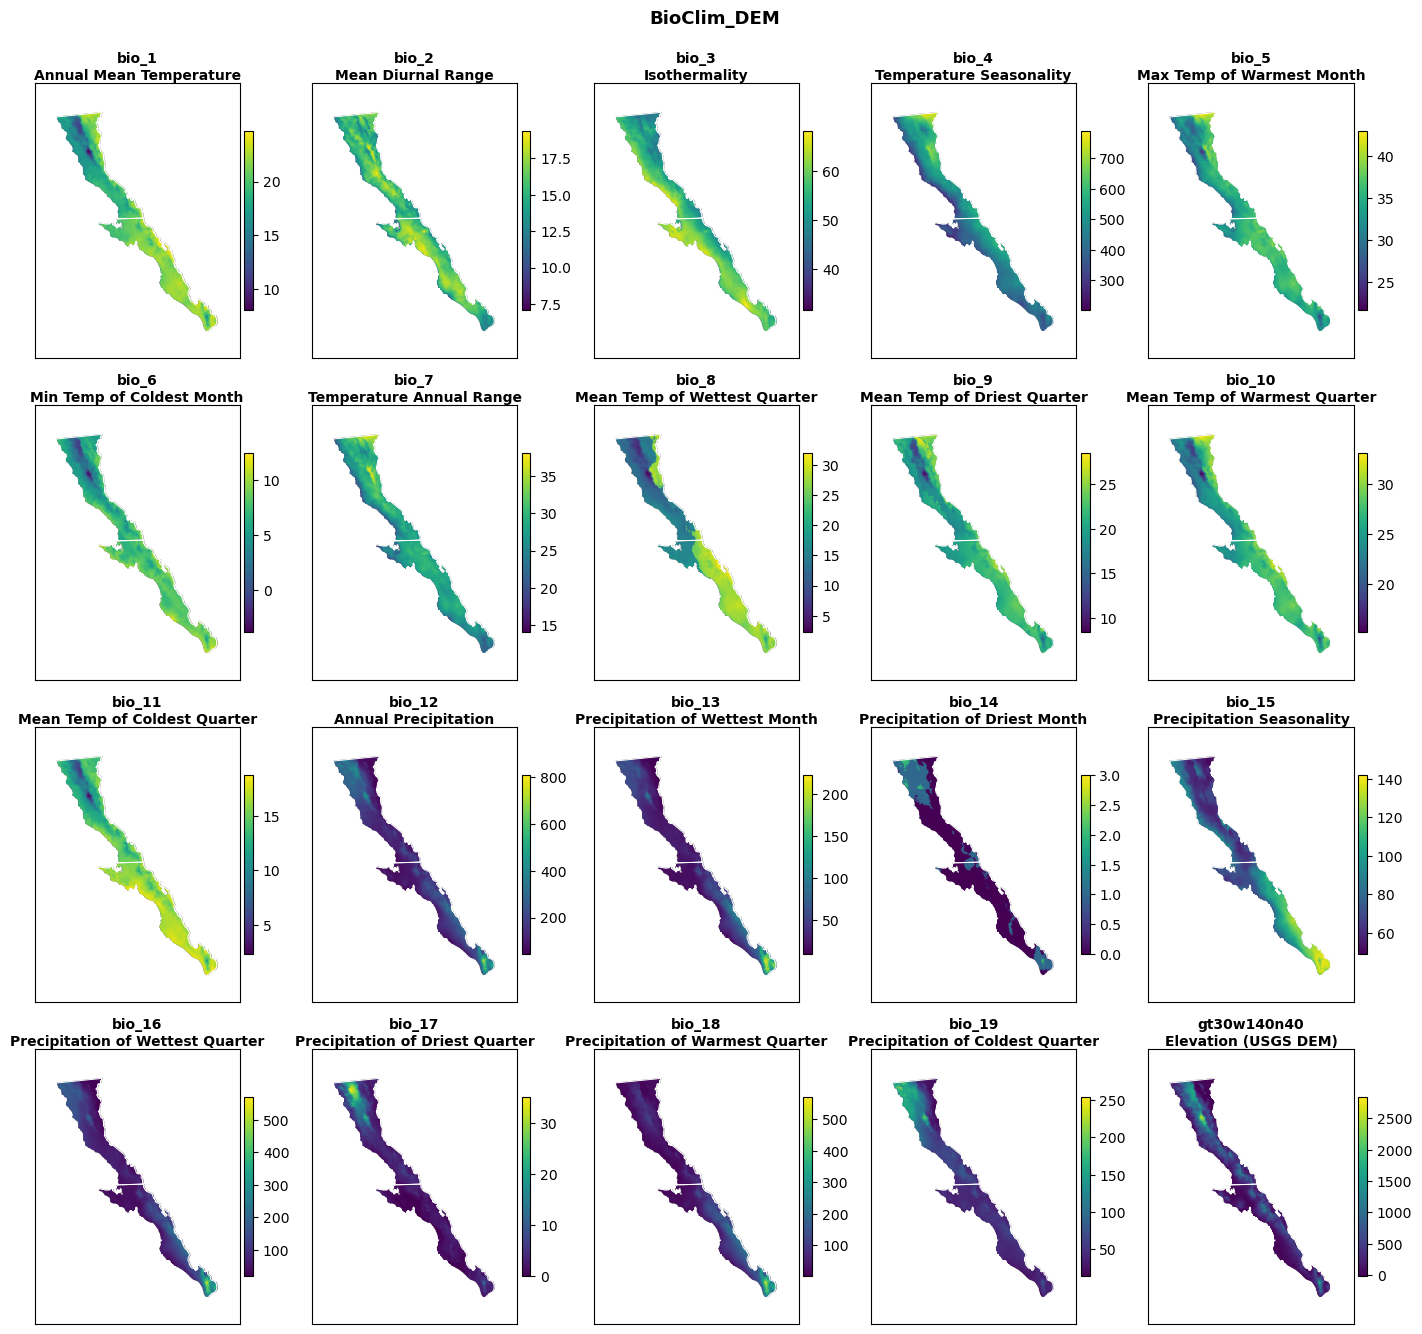

Saved → Processed/03_vars_BioClim_DEM.png


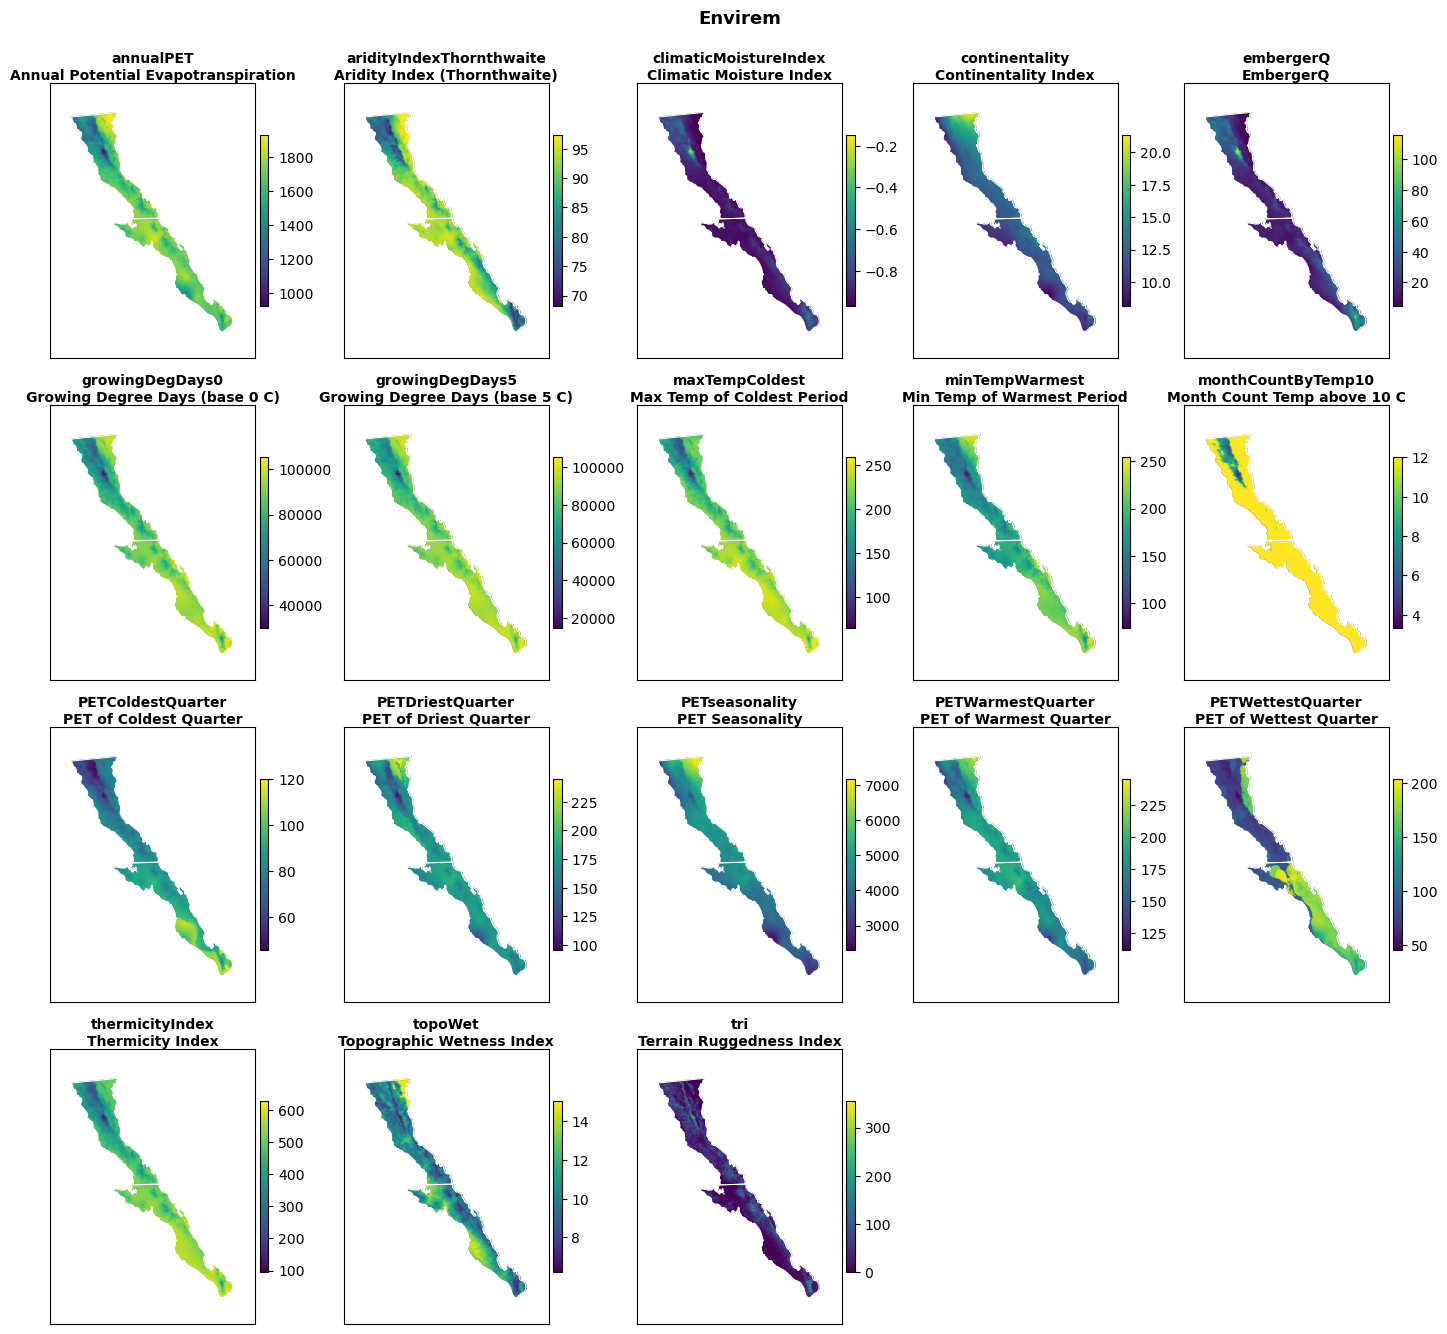

Saved → Processed/03_vars_Envirem.png


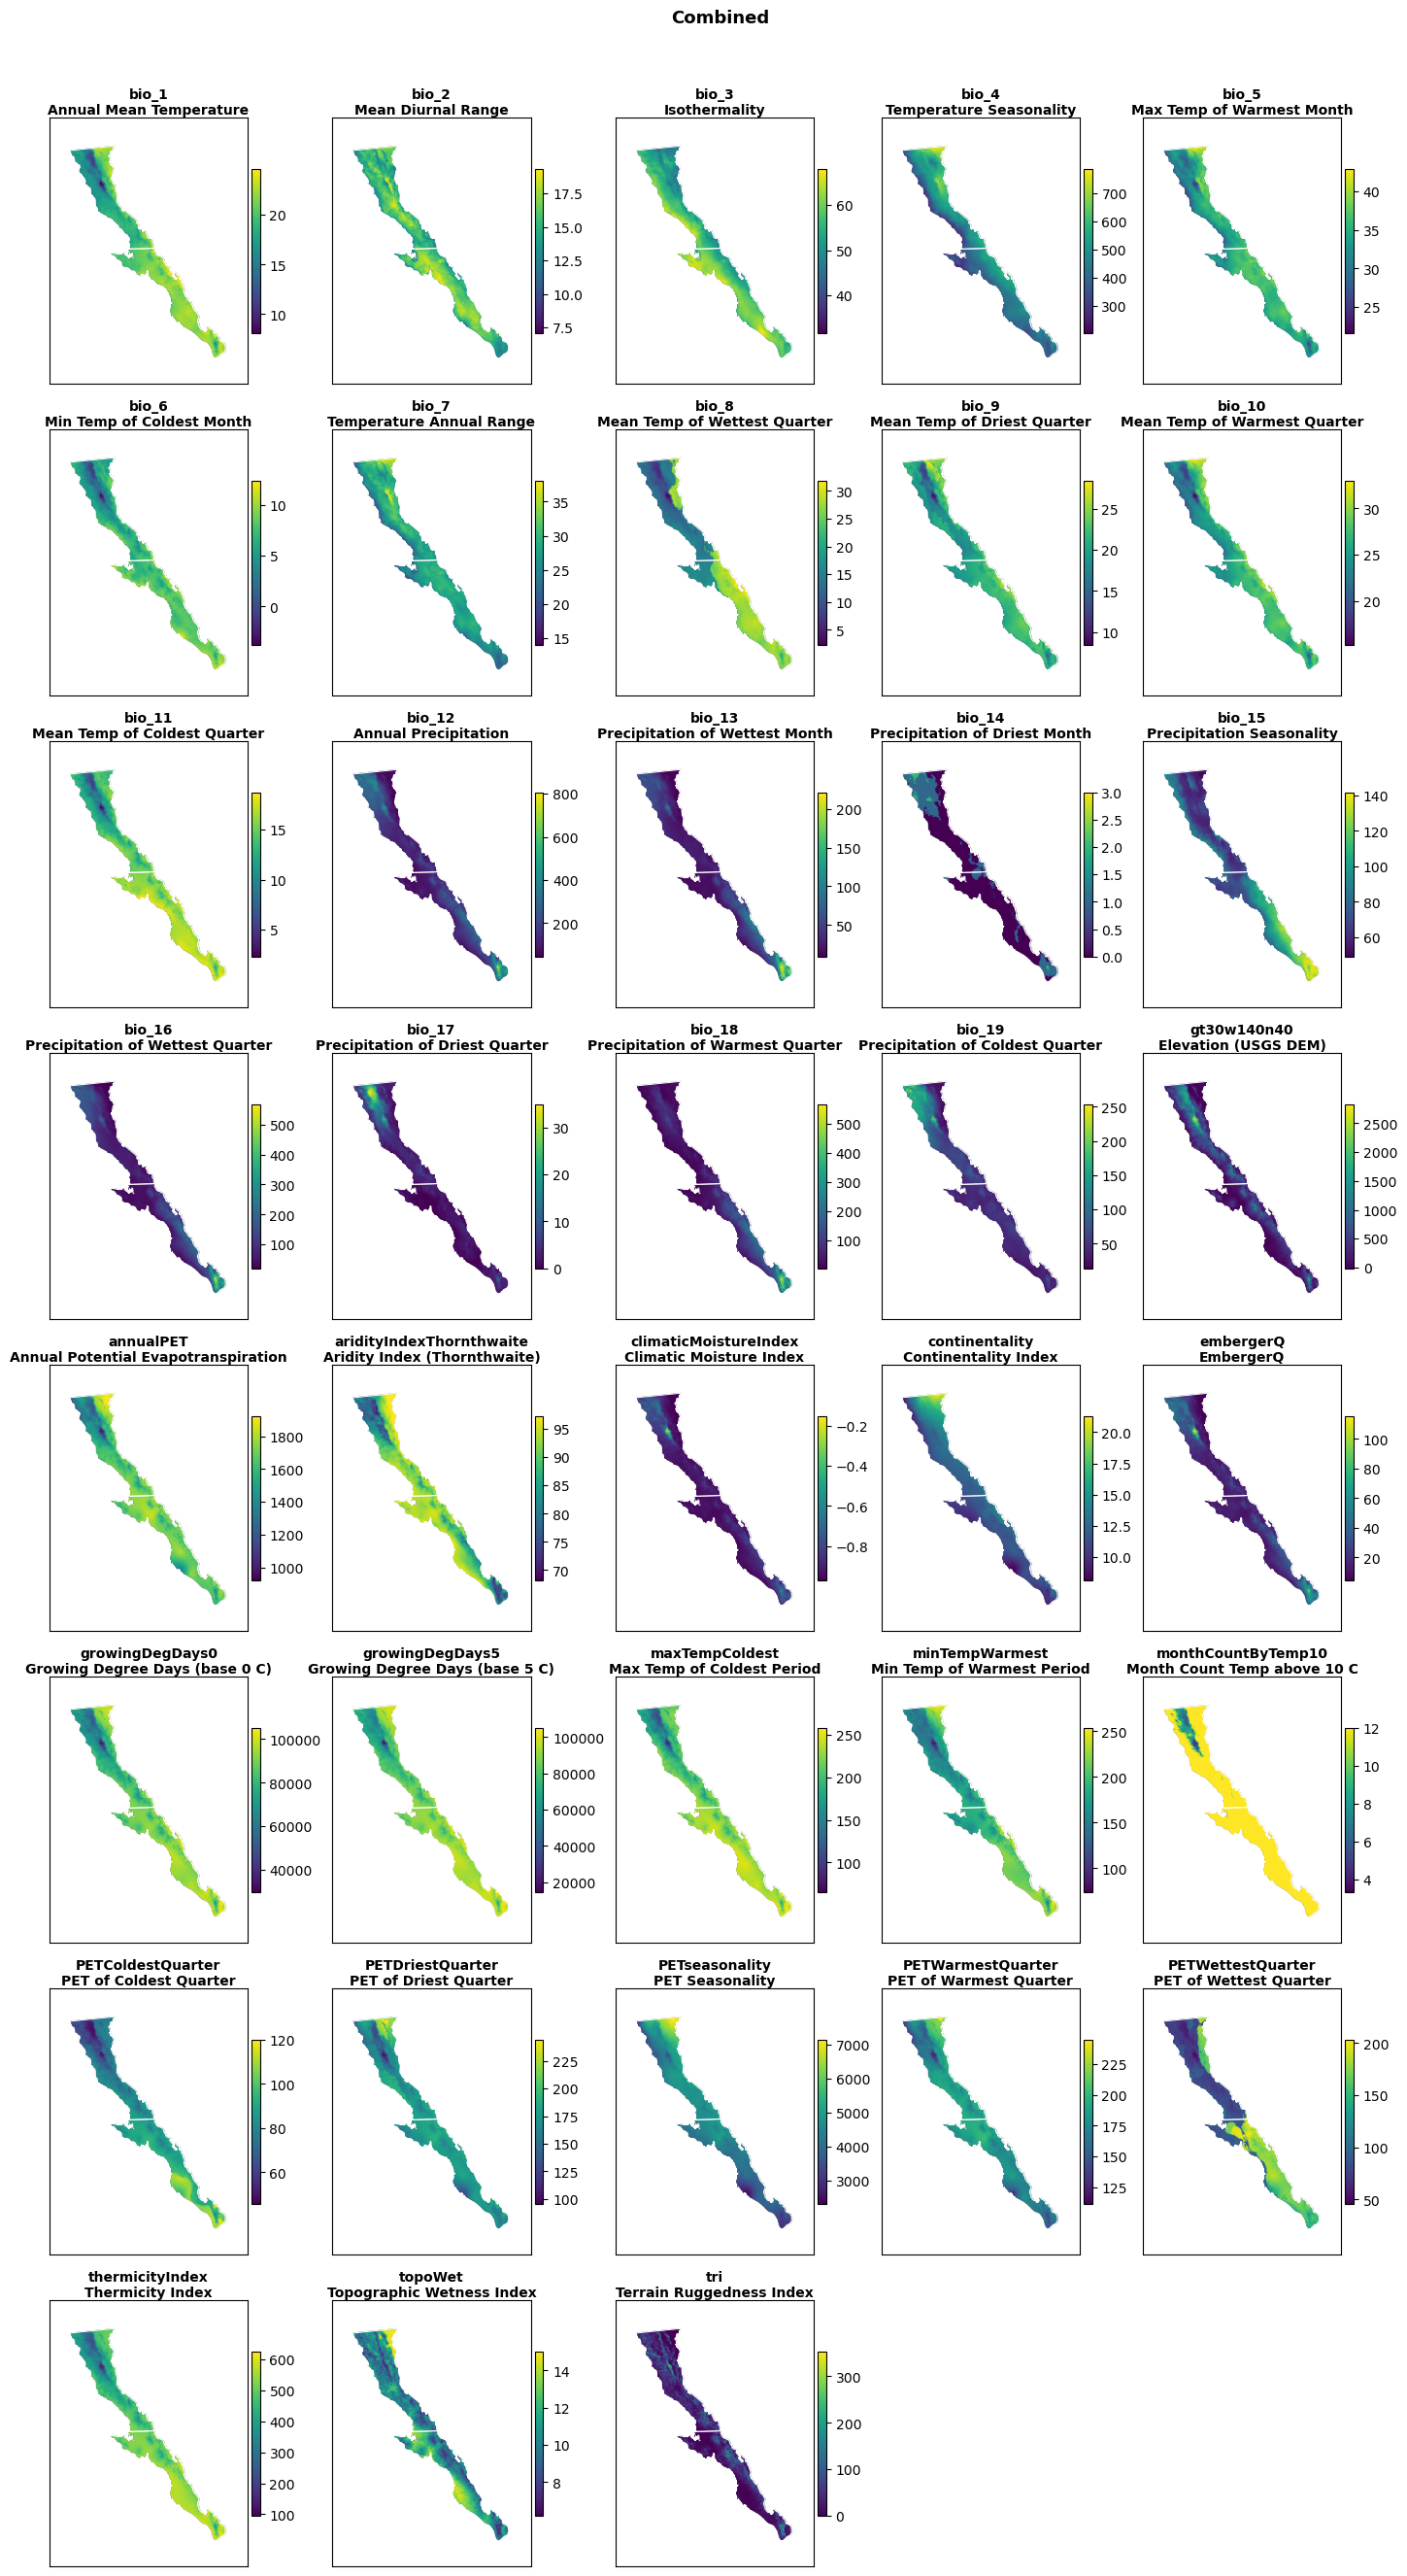

Saved → Processed/03_vars_Combined.png


In [16]:
def visualize_var_set(names_dict, set_label):
    """Plot all processed variables in a set as a grid of maps."""
    ncols = 5
    nrows = math.ceil(len(names_dict) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 2.8, nrows * 3.2),
        constrained_layout=True
    )
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.04, wspace=0.0, hspace=0.05)
    axes = axes.flatten()

    for i, (varname, fullname) in enumerate(names_dict.items()):
        ax = axes[i]
        data = processed[varname].copy().astype(float)
        data[data == NODATA_VALUE] = np.nan
        im = ax.imshow(data, extent=RASTER_EXTENT, origin='upper', cmap='viridis', aspect='equal')
        study_area.plot(ax=ax, color='none', edgecolor='white', linewidth=0.7)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        ax.set_title(f'{varname}\n{fullname}', fontsize=10, fontweight='bold', pad=3)
        ax.set_xticks([])
        ax.set_yticks([])

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(set_label, fontsize=13, fontweight='bold', y=1.03)
    out_path = os.path.join(OUTPUT_DIR, f'03_vars_{_safe_filename(set_label)}.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

# Visualize each variable set
for set_name, var_keys in VARIABLE_SETS.items():
    names_dict = {k: ALL_NAMES.get(k, k) for k in var_keys if k in processed}
    visualize_var_set(names_dict, set_name)

### 4.4. Export Processed Rasters

In [17]:
# ── Export all processed rasters with full descriptive filenames ───────────────
raster_profile = {
    'driver'   : 'GTiff',
    'dtype'    : 'float32',
    'width'    : GRID_WIDTH,
    'height'   : GRID_HEIGHT,
    'count'    : 1,
    'crs'      : REFERENCE_CRS,
    'transform': REFERENCE_TRANSFORM,
    'nodata'   : NODATA_VALUE,
    'compress' : 'lzw',
}

for name, data in tqdm(processed.items(), desc='Saving rasters', unit='file'):
    file_stem = _safe_filename(ALL_NAMES.get(name, name))
    out_path  = os.path.join(destination_dir[name], f'{file_stem}.tif')
    with rasterio.open(out_path, 'w', **raster_profile) as dst:
        dst.write(data.astype(np.float32), 1)

print(f'Done: {len(processed)} rasters saved to {OUTPUT_DIR}/')

Saving rasters:   0%|          | 0/38 [00:00<?, ?file/s]

Done: 38 rasters saved to Processed/


## 5. Variable Selection

### 5.1 Prior Deduplication
> ✎ **Manually exclude variables that overlap conceptually with others across any source.** They are removed from all `VARIABLE_SETS` entries automatically.

In [18]:
# Variables to DROP before multicollinearity screening.
    # To keep a variable: remove it from this list.
    # To drop a variable: add its key with a brief reason in the comment.

VARS_TO_DROP = [
    'continentality',    # redundant with bio_7 — Temperature Annual Range
    'growingDegDays5',   # redundant with growingDegDays0; base-5 shift adds nothing
    'thermicityIndex',   # weighted sum of BioClim temperature vars — fully redundant
]

# Apply VARS_TO_DROP across all variable sets
VARIABLE_SETS = {
    name: [k for k in keys if k not in VARS_TO_DROP]
    for name, keys in VARIABLE_SETS.items()
}

print(f'Dropped : {VARS_TO_DROP}')
print(f'\nVariable sets after filtering:')
for name, keys in VARIABLE_SETS.items():
    print(f'  {name}: {len(keys)} variables')

Dropped : ['continentality', 'growingDegDays5', 'thermicityIndex']

Variable sets after filtering:
  BioClim_DEM: 20 variables
  Envirem: 15 variables
  Combined: 35 variables


### 5.2 Multicollinearity Screening
> ✎ **Adjust correlation threshold below if needed.** 0.70 = conservative (smaller final set); 0.85 = recommended; 0.90 = lenient 

In [19]:
# ── Correlation Threshold ─────────────────────────────────────────────────────

CORRELATION_THRESHOLD = 0.85

In [20]:
# ── Helper functions for correlation analysis ─────────────────────────────────

def corr_matrix(var_list):
    """Pearson correlation matrix across valid study area pixels."""
    data = np.stack([processed[v][valid_mask].astype(np.float64) for v in var_list], axis=1)
    return pd.DataFrame(np.corrcoef(data.T), index=var_list, columns=var_list)

def iterative_drop(corr_df, threshold=CORRELATION_THRESHOLD):
    """Iteratively remove the variable with the most high-correlation partners."""
    remaining = list(corr_df.columns)
    dropped = []
    while True:
        sub = corr_df.loc[remaining, remaining].abs()
        np.fill_diagonal(sub.values, 0)
        counts = (sub > threshold).sum(axis=1)
        if counts.max() == 0:
            break
        dropped.append(counts.idxmax())
        remaining.remove(dropped[-1])
    return dropped, remaining

def plot_corr(corr_df, threshold, title):
    """Lower-triangle heatmap; red borders mark pairs above threshold."""
    n = len(corr_df)
    sz = min(18, max(8, n * 0.62))
    fig, ax = plt.subplots(figsize=(sz, sz * 0.9))
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                square=True, linewidths=0.3, ax=ax,
                cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
    for i in range(n):
        for j in range(i):
            if abs(corr_df.iloc[i, j]) > threshold:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                           edgecolor='red', lw=2, zorder=3))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    return fig

── BioClim_DEM  20 → 14 variables  (dropped 6)
   Dropped : ['bio_1', 'bio_13', 'bio_10', 'bio_3', 'bio_6', 'bio_12']
   bio_13 × bio_16  |r| = 0.979
   bio_6 × bio_11  |r| = 0.953
   bio_12 × bio_16  |r| = 0.945
   bio_1 × bio_10  |r| = 0.916
   bio_13 × bio_18  |r| = 0.911
   bio_5 × bio_10  |r| = 0.908
   bio_1 × bio_11  |r| = 0.902
   bio_12 × bio_13  |r| = 0.885
   bio_9 × bio_10  |r| = 0.877
   bio_3 × bio_4  |r| = 0.868
   bio_1 × bio_9  |r| = 0.858
   bio_1 × bio_6  |r| = 0.854



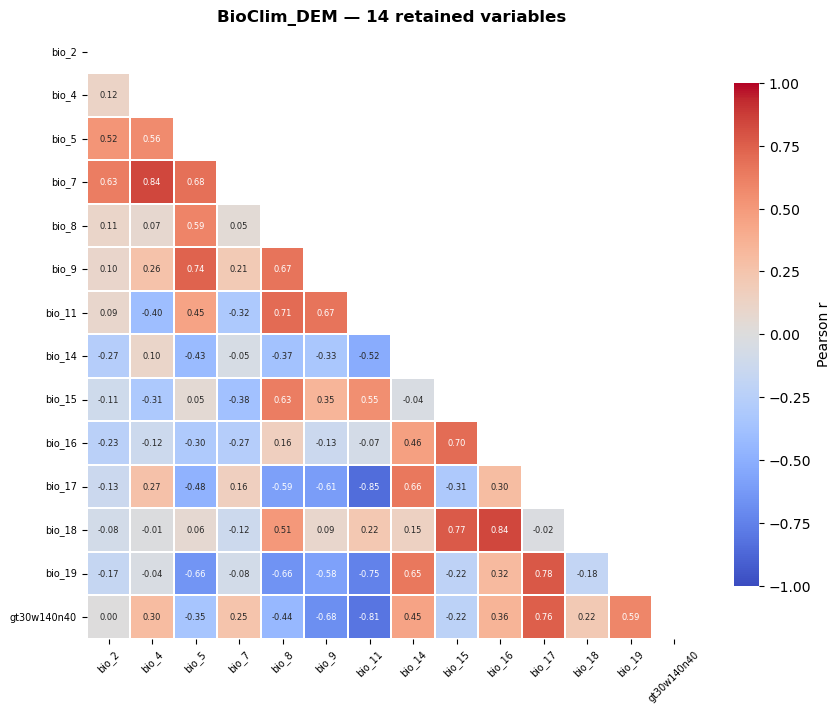

── Envirem  15 → 11 variables  (dropped 4)
   Dropped : ['growingDegDays0', 'aridityIndexThornthwaite', 'climaticMoistureIndex', 'maxTempColdest']
   climaticMoistureIndex × embergerQ  |r| = 0.957
   growingDegDays0 × maxTempColdest  |r| = 0.942
   growingDegDays0 × minTempWarmest  |r| = 0.930
   aridityIndexThornthwaite × embergerQ  |r| = 0.927
   aridityIndexThornthwaite × climaticMoistureIndex  |r| = 0.917
   maxTempColdest × PETColdestQuarter  |r| = 0.914
   annualPET × growingDegDays0  |r| = 0.867



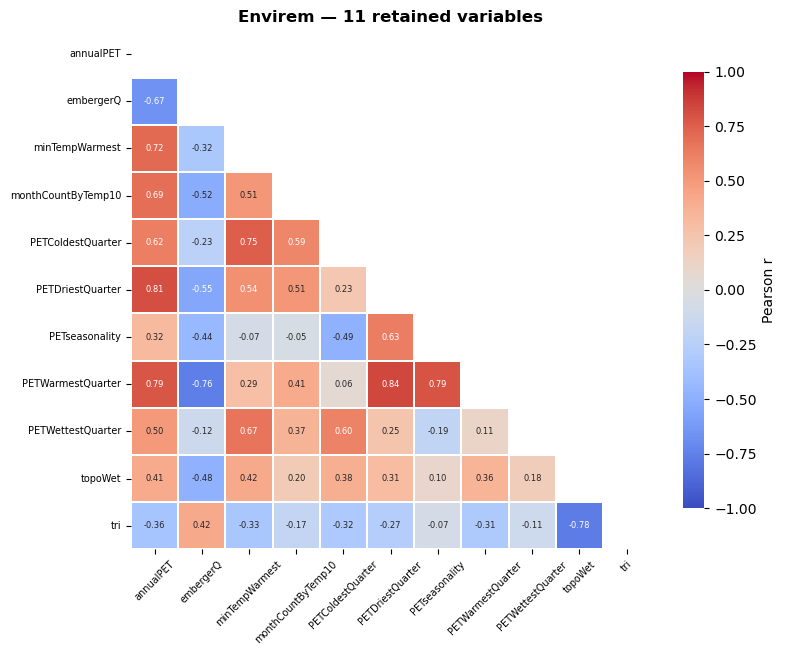

── Combined  35 → 24 variables  (dropped 11)
   Dropped : ['bio_1', 'maxTempColdest', 'bio_12', 'growingDegDays0', 'bio_10', 'bio_11', 'bio_13', 'aridityIndexThornthwaite', 'bio_3', 'bio_17', 'climaticMoistureIndex']
   bio_13 × bio_16  |r| = 0.979
   bio_11 × maxTempColdest  |r| = 0.961
   climaticMoistureIndex × embergerQ  |r| = 0.957
   bio_6 × bio_11  |r| = 0.953
   bio_12 × bio_16  |r| = 0.945
   growingDegDays0 × maxTempColdest  |r| = 0.942
   bio_1 × growingDegDays0  |r| = 0.940
   growingDegDays0 × minTempWarmest  |r| = 0.930
   aridityIndexThornthwaite × embergerQ  |r| = 0.927
   bio_12 × embergerQ  |r| = 0.922
   aridityIndexThornthwaite × climaticMoistureIndex  |r| = 0.917
   bio_1 × bio_10  |r| = 0.916
   bio_11 × growingDegDays0  |r| = 0.916
   maxTempColdest × PETColdestQuarter  |r| = 0.914
   bio_13 × bio_18  |r| = 0.911
   bio_12 × aridityIndexThornthwaite  |r| = 0.908
   bio_5 × bio_10  |r| = 0.908
   bio_1 × bio_11  |r| = 0.902
   bio_6 × maxTempColdest  |r| = 0.899
 

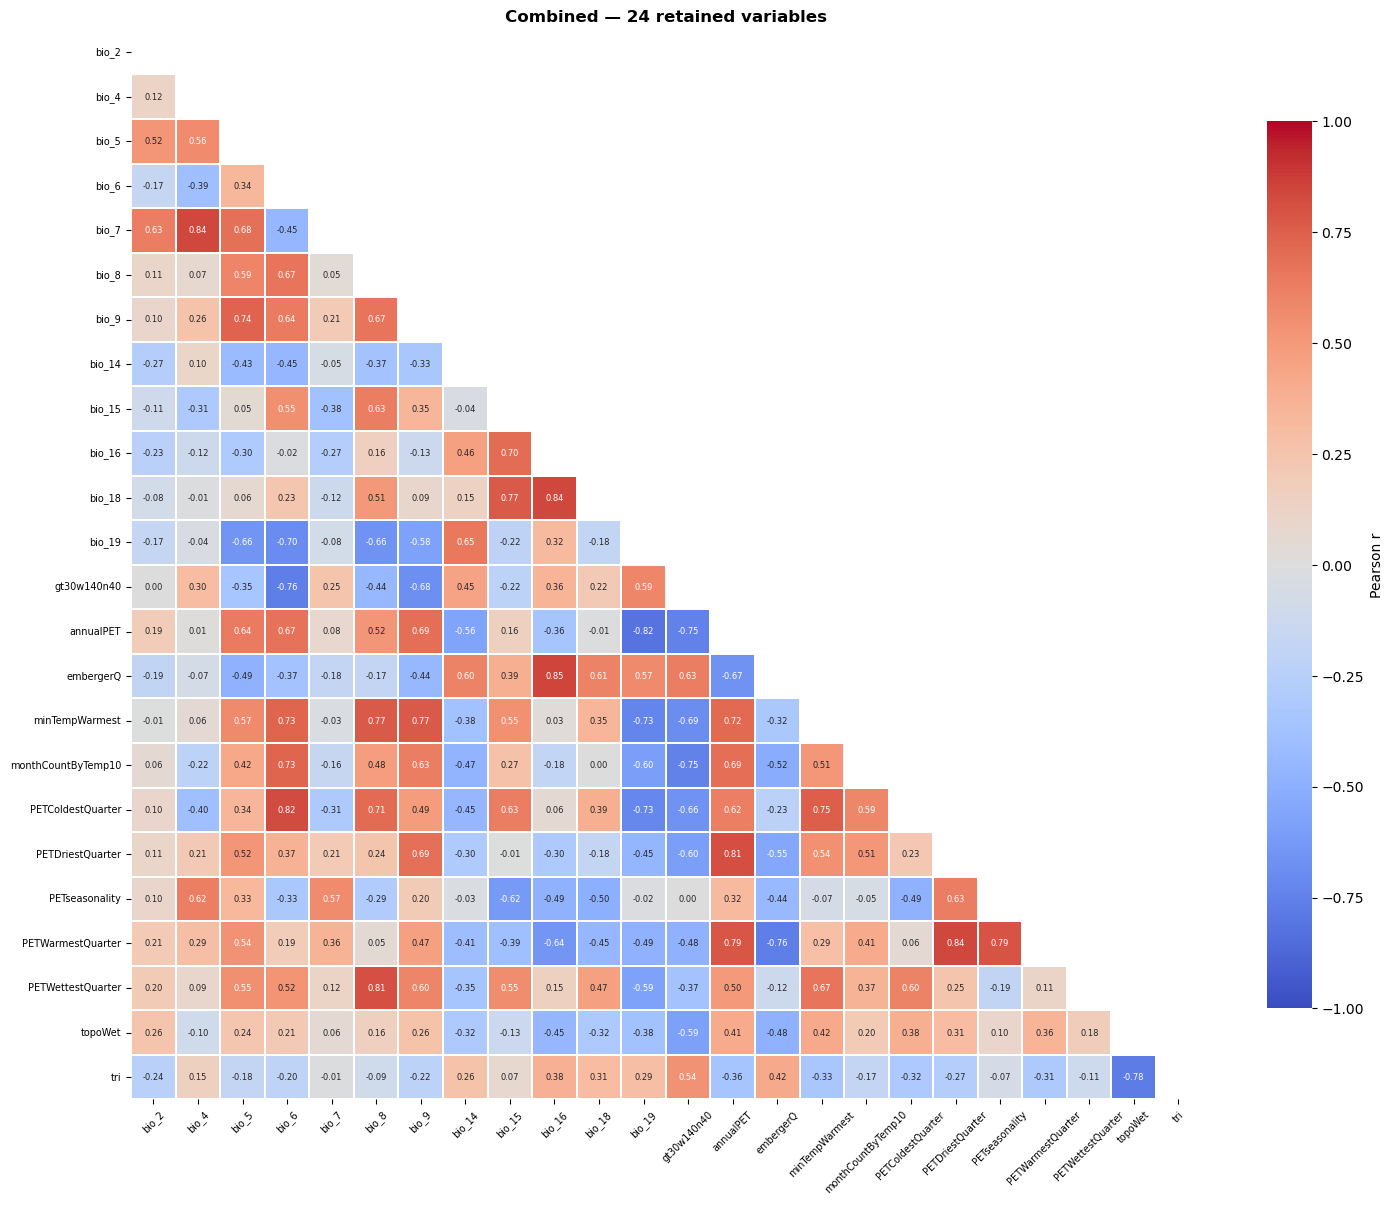

In [21]:
# ── Multicollinearity screening — runs for every set in VARIABLE_SETS ─────────
FINAL_VARS = {} 

for set_name, var_list in VARIABLE_SETS.items():
    corr_full = corr_matrix(var_list)
    dropped, remaining = iterative_drop(corr_full)
    FINAL_VARS[set_name] = remaining

    high_pairs = [(v1, v2, corr_full.loc[v1, v2])
                  for i, v1 in enumerate(var_list)
                  for v2 in var_list[i+1:]
                  if abs(corr_full.loc[v1, v2]) > CORRELATION_THRESHOLD]

    print(f'── {set_name}  {len(var_list)} → {len(remaining)} variables  (dropped {len(dropped)})')
    if dropped:
        print(f'   Dropped : {dropped}')
    if high_pairs:
        for v1, v2, r in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f'   {v1} × {v2}  |r| = {abs(r):.3f}')
    print()

    fig = plot_corr(corr_matrix(remaining), CORRELATION_THRESHOLD,
                    f'{set_name} — {len(remaining)} retained variables')
    fig.savefig(os.path.join(OUTPUT_DIR, f'04_corr_{_safe_filename(set_name)}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()

In [22]:
# ── Final variable lists — loops over all sets in FINAL_VARS ──────────────────
def make_var_df(var_list):
    rows = []
    for v in var_list:
        full    = ALL_NAMES.get(v, v)
        out_dir = destination_dir.get(v, '')
        src     = os.path.basename(out_dir) if out_dir else 'Unknown'
        rows.append({'Variable': v, 'Full name': full,
                     'Filename': _safe_filename(full) + '.tif', 'Source': src})
    return pd.DataFrame(rows)

for set_name, var_list in FINAL_VARS.items():
    df = make_var_df(var_list)
    print(f'=== {set_name}  ({len(df)} variables) ===')
    display(df.set_index('Variable'))
    path = os.path.join(OUTPUT_DIR, f'final_vars_{_safe_filename(set_name)}.csv')
    df.to_csv(path, index=False)
    print(f'Saved → {path}\n')

=== BioClim_DEM  (14 variables) ===


,Full name,Filename,Source
Variable,,,
bio_2,Mean Diurnal Range,Mean_Diurnal_Range.tif,BioClim
bio_4,Temperature Seasonality,Temperature_Seasonality.tif,BioClim
bio_5,Max Temp of Warmest Month,Max_Temp_of_Warmest_Month.tif,BioClim
bio_7,Temperature Annual Range,Temperature_Annual_Range.tif,BioClim
bio_8,Mean Temp of Wettest Quarter,Mean_Temp_of_Wettest_Quarter.tif,BioClim
bio_9,Mean Temp of Driest Quarter,Mean_Temp_of_Driest_Quarter.tif,BioClim
bio_11,Mean Temp of Coldest Quarter,Mean_Temp_of_Coldest_Quarter.tif,BioClim
bio_14,Precipitation of Driest Month,Precipitation_of_Driest_Month.tif,BioClim
bio_15,Precipitation Seasonality,Precipitation_Seasonality.tif,BioClim


Saved → Processed/final_vars_BioClim_DEM.csv

=== Envirem  (11 variables) ===


,Full name,Filename,Source
Variable,,,
annualPET,Annual Potential Evapotranspiration,Annual_Potential_Evapotranspiration.tif,Envirem
embergerQ,EmbergerQ,EmbergerQ.tif,Envirem
minTempWarmest,Min Temp of Warmest Period,Min_Temp_of_Warmest_Period.tif,Envirem
monthCountByTemp10,Month Count Temp above 10 C,Month_Count_Temp_above_10_C.tif,Envirem
PETColdestQuarter,PET of Coldest Quarter,PET_of_Coldest_Quarter.tif,Envirem
PETDriestQuarter,PET of Driest Quarter,PET_of_Driest_Quarter.tif,Envirem
PETseasonality,PET Seasonality,PET_Seasonality.tif,Envirem
PETWarmestQuarter,PET of Warmest Quarter,PET_of_Warmest_Quarter.tif,Envirem
PETWettestQuarter,PET of Wettest Quarter,PET_of_Wettest_Quarter.tif,Envirem


Saved → Processed/final_vars_Envirem.csv

=== Combined  (24 variables) ===


,Full name,Filename,Source
Variable,,,
bio_2,Mean Diurnal Range,Mean_Diurnal_Range.tif,BioClim
bio_4,Temperature Seasonality,Temperature_Seasonality.tif,BioClim
bio_5,Max Temp of Warmest Month,Max_Temp_of_Warmest_Month.tif,BioClim
bio_6,Min Temp of Coldest Month,Min_Temp_of_Coldest_Month.tif,BioClim
bio_7,Temperature Annual Range,Temperature_Annual_Range.tif,BioClim
bio_8,Mean Temp of Wettest Quarter,Mean_Temp_of_Wettest_Quarter.tif,BioClim
bio_9,Mean Temp of Driest Quarter,Mean_Temp_of_Driest_Quarter.tif,BioClim
bio_14,Precipitation of Driest Month,Precipitation_of_Driest_Month.tif,BioClim
bio_15,Precipitation Seasonality,Precipitation_Seasonality.tif,BioClim


Saved → Processed/final_vars_Combined.csv

